# **Predictive Analytics & Financial Modeling**
# **Loan Default Prediction using Machine Learning generate**
## Name: Rachana Baddam


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_feather("lending_club_clean_small.feather")

print(df.shape)
df.head()

(200000, 142)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,bad_payer
0,78428548,6400,6400,6400.0,36,0.1367,217.720001,C,C3,Web Support Analist,...,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N,0.0
1,136264733,35000,35000,35000.0,36,0.1691,1246.280029,C,C5,Vice President,...,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N,1.0
2,141294472,10000,10000,10000.0,36,0.1797,361.380005,D,D1,Dispatcher 3,...,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N,0.0
3,95218480,35000,35000,35000.0,36,0.1049,1137.430054,B,B2,Emergency Physician,...,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N,0.0
4,112117439,3500,3500,3500.0,36,0.1091,114.440002,B,B4,Grocery,...,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 142 entries, id to bad_payer
dtypes: Int16(54), Int32(15), Int64(15), category(22), datetime64[ns](9), float32(26), float64(1)
memory usage: 222.1 MB


In [4]:
cols = [
    'loan_amnt',
    'funded_amnt',
    'funded_amnt_inv',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'dti',
    'bad_payer'
]

df = df[cols]

df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,dti,bad_payer
0,6400,6400,6400.0,36,0.1367,217.720001,C,C3,3 years,MORTGAGE,55000.0,21.360001,0.0
1,35000,35000,35000.0,36,0.1691,1246.280029,C,C5,< 1 year,OWN,195000.0,3.350000,1.0
2,10000,10000,10000.0,36,0.1797,361.380005,D,D1,10+ years,MORTGAGE,95000.0,27.160000,0.0
3,35000,35000,35000.0,36,0.1049,1137.430054,B,B2,< 1 year,MORTGAGE,380000.0,8.920000,0.0
4,3500,3500,3500.0,36,0.1091,114.440002,B,B4,2 years,RENT,25000.0,16.809999,0.0


In [5]:
df = df.replace(-1, np.nan)
df = df.dropna()

df.shape

(187533, 13)

In [6]:
df['bad_payer'].value_counts()

bad_payer
0.0    151782
1.0     35751
Name: count, dtype: int64

In [7]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,dti,bad_payer,grade_B,...,emp_length_6 years,emp_length_7 years,emp_length_8 years,emp_length_9 years,emp_length_< 1 year,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,6400,6400,6400.0,36,0.1367,217.720001,55000.0,21.360001,0.0,False,...,False,False,False,False,False,True,False,False,False,False
1,35000,35000,35000.0,36,0.1691,1246.280029,195000.0,3.350000,1.0,False,...,False,False,False,False,True,False,False,False,True,False
2,10000,10000,10000.0,36,0.1797,361.380005,95000.0,27.160000,0.0,False,...,False,False,False,False,False,True,False,False,False,False
3,35000,35000,35000.0,36,0.1049,1137.430054,380000.0,8.920000,0.0,True,...,False,False,False,False,True,True,False,False,False,False
4,3500,3500,3500.0,36,0.1091,114.440002,25000.0,16.809999,0.0,True,...,False,False,False,False,False,False,False,False,False,True


In [8]:
X = df.drop('bad_payer', axis=1)
y = df['bad_payer']

In [9]:
X = df.drop('bad_payer', axis=1)
y = df['bad_payer']

# convert everything to numeric float
X = X.astype(float)

In [10]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_res, y_res = sm.fit_resample(X, y)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8836493008087231
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89     30295
         1.0       0.95      0.81      0.88     30418

    accuracy                           0.88     60713
   macro avg       0.89      0.88      0.88     60713
weighted avg       0.89      0.88      0.88     60713



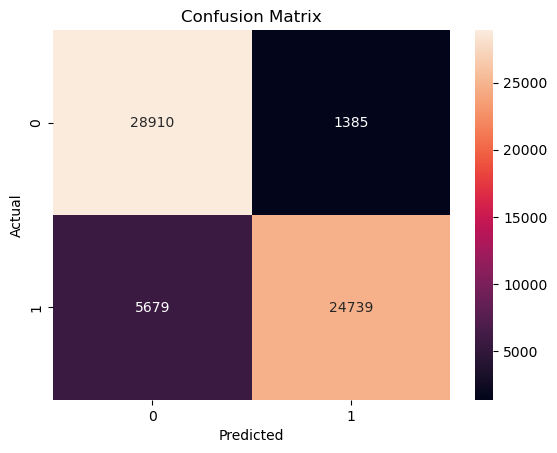

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()